# Molinaro et al. (2024) hip exoskeleton dataset — loading & exploration

Raw data for **"Estimating human joint moments unifies exoskeleton control and reduces user effort"**
(Molinaro, Kang & Young, *Science Robotics* 9, eadi8852) — [Zenodo 10849318](https://zenodo.org/records/10849318).

**Layout:** `AB<subject>/<trial>/{angle,exo,gp,grf,moment}.csv`, all sampled at **200 Hz**.
Within a trial the five files share an identical `time` column, so they join positionally.

**Trial name grammar:** `<MODE>_C<condition>_S<speed>_<CONTROLLER>[_<idx>...]`
where `p` = decimal point and `n` = minus (`Cn12p7` = -12.7°).

| Field | Values |
|---|---|
| Mode | `LG` level ground, `RA`/`RD` ramp asc/desc, `SA`/`SD` stair asc/desc, `ST` standing, `TR`/`TRA`/`TRB` transitions |
| Condition | ramp slope in degrees, or stair height in cm (`C0p0` if neither) |
| Speed | m/s (`S0p0` for overground / standing) |
| Controller | `BT` biological-torque spline, `ET` experimenter-tuned spline, `UC` unified moment controller |

**Sign convention:** extension / plantarflexion positive; flexion / dorsiflexion negative.

In [32]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(marker: str = "data/molinaro-raw") -> Path:
    """Walk up from the CWD until we find the directory holding the dataset."""
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_dir():
            return d
    raise FileNotFoundError(f"could not locate {marker!r} above {Path.cwd()}")


REPO = find_repo_root()
DATA_ROOT = REPO / "data" / "molinaro-raw"
CACHE = REPO / "data" / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

print("repo     :", REPO)
print("data root:", DATA_ROOT)
print("subjects :", len(sorted(DATA_ROOT.glob("AB*"))))

repo     : /Users/dariussattari/Documents/thesis/Uncertainty-Aware-Hip-Exoskeleton
data root: /Users/dariussattari/Documents/thesis/Uncertainty-Aware-Hip-Exoskeleton/data/molinaro-raw
subjects : 34


In [34]:
# ---- dataset constants (from the dataset README) -------------------------------

SAMPLE_RATE_HZ = 200
DT = 1.0 / SAMPLE_RATE_HZ

FILES = ["angle", "exo", "gp", "grf", "moment"]

# Data-collection phases: phase -> (first subject, last subject)
PHASES = {1: (1, 9), 2: (10, 14), 3: (15, 24), 4: (25, 34)}

# AB01-AB09 used the Samsung GEMS exo; their thigh/shank/pelvis IMU data were
# *transformed* into the custom exo's coordinate frames. AB10-AB34 used the custom hip exo.
GEMS_SUBJECTS = {f"AB{i:02d}" for i in range(1, 10)}

# Controller-software bug: trq_mea_l / trq_mea_r are all-NaN for these subjects.
NO_TRQ_MEA_SUBJECTS = {f"AB{i:02d}" for i in range(10, 15)}

# ---- channel groups -----------------------------------------------------------

ENCODER = ["enc_angle_l", "enc_angle_r", "enc_velo_l", "enc_velo_r"]

THIGH_IMU = [
    f"thigh_{sig}_{ax}_{side}"
    for side in ("l", "r")
    for sig in ("accel", "gyro")
    for ax in ("x", "y", "z")
]

PELVIS_IMU = [f"pelvis_{sig}_{ax}" for sig in ("accel", "gyro") for ax in ("x", "y", "z")]

TORQUE = ["trq_est_l", "trq_cmd_l", "trq_mea_l", "trq_est_r", "trq_cmd_r", "trq_mea_r"]

# The 16 channels that mirror the ankle uncertainty paper's input set
# (accel xyz, gyro xyz, joint angle, joint velocity -- bilateral).
INPUT_16 = ENCODER + THIGH_IMU
# ...plus the pelvis IMU, which the ankle exo had no equivalent for.
INPUT_22 = INPUT_16 + PELVIS_IMU

GAIT_PHASE = ["gp_to_l", "gp_hs_l", "gp_to_r", "gp_hs_r"]
HIP_MOMENT = ["hip_moment_l", "hip_moment_r"]

assert len(INPUT_16) == 16 and len(INPUT_22) == 22
print(f"INPUT_16 ({len(INPUT_16)}): {INPUT_16}")
print(f"\nPELVIS_IMU ({len(PELVIS_IMU)}): {PELVIS_IMU}")

INPUT_16 (16): ['enc_angle_l', 'enc_angle_r', 'enc_velo_l', 'enc_velo_r', 'thigh_accel_x_l', 'thigh_accel_y_l', 'thigh_accel_z_l', 'thigh_gyro_x_l', 'thigh_gyro_y_l', 'thigh_gyro_z_l', 'thigh_accel_x_r', 'thigh_accel_y_r', 'thigh_accel_z_r', 'thigh_gyro_x_r', 'thigh_gyro_y_r', 'thigh_gyro_z_r']

PELVIS_IMU (6): ['pelvis_accel_x', 'pelvis_accel_y', 'pelvis_accel_z', 'pelvis_gyro_x', 'pelvis_gyro_y', 'pelvis_gyro_z']


## 1. Trial inventory

Parse every trial folder name into structured metadata. This is cheap (directory names only,
plus a line count per trial for duration) and gets cached to Parquet.

In [35]:
TRIAL_RE = re.compile(
    r"^(?P<mode>[A-Z]+?)"
    r"_C(?P<condition>n?\d+p\d+)"
    r"_S(?P<speed>n?\d+p\d+)"
    r"_(?P<controller>[A-Z]{2})"
    r"(?:_(?P<index>.+))?$"
)


def _num(token: str) -> float:
    """'n12p7' -> -12.7, '1p25' -> 1.25"""
    return float(token.replace("p", ".").replace("n", "-", 1))


def phase_of(subject: str) -> int:
    n = int(subject[2:])
    for phase, (lo, hi) in PHASES.items():
        if lo <= n <= hi:
            return phase
    raise ValueError(f"no phase for {subject}")


def parse_trial_name(name: str) -> dict:
    m = TRIAL_RE.match(name)
    if m is None:
        raise ValueError(f"unparseable trial name: {name!r}")
    g = m.groupdict()
    return {
        "mode": g["mode"],
        "condition": _num(g["condition"]),
        "speed": _num(g["speed"]),
        "controller": g["controller"],
        "rep_index": g["index"] or "",
    }


def _count_samples(path: Path) -> int:
    """Row count (excluding header) via a fast byte-level newline count."""
    with open(path, "rb") as fh:
        n = sum(buf.count(b"\n") for buf in iter(lambda: fh.read(1 << 20), b""))
    return max(n - 1, 0)


print(parse_trial_name("SD_Cn17p8_S0p0_UC_1_18"))
print(parse_trial_name("LG_C0p0_S1p25_UC_1"))

{'mode': 'SD', 'condition': -17.8, 'speed': 0.0, 'controller': 'UC', 'rep_index': '1_18'}
{'mode': 'LG', 'condition': 0.0, 'speed': 1.25, 'controller': 'UC', 'rep_index': '1'}


In [36]:
def build_inventory(with_duration: bool = True) -> pd.DataFrame:
    rows = []
    for subj_dir in sorted(DATA_ROOT.glob("AB*")):
        if not subj_dir.is_dir():
            continue
        subject = subj_dir.name
        for trial_dir in sorted(p for p in subj_dir.iterdir() if p.is_dir()):
            present = {f: (trial_dir / f"{f}.csv").exists() for f in FILES}
            rec = {"subject": subject, "trial": trial_dir.name, **parse_trial_name(trial_dir.name)}
            rec["phase"] = phase_of(subject)
            rec["exo_hardware"] = "GEMS" if subject in GEMS_SUBJECTS else "custom"
            rec["has_trq_mea"] = subject not in NO_TRQ_MEA_SUBJECTS
            rec["n_files"] = sum(present.values())
            rec["complete"] = all(present.values())
            if with_duration and present["gp"]:
                n = _count_samples(trial_dir / "gp.csv")
                rec["n_samples"] = n
                rec["duration_s"] = n * DT
            rows.append(rec)
    df = pd.DataFrame(rows)
    cat = ["subject", "mode", "controller", "exo_hardware"]
    df[cat] = df[cat].astype("category")
    return df


INVENTORY_PATH = CACHE / "inventory.parquet"

if INVENTORY_PATH.exists():
    inventory = pd.read_parquet(INVENTORY_PATH)
    print(f"loaded cached inventory: {INVENTORY_PATH}")
else:
    inventory = build_inventory()
    inventory.to_parquet(INVENTORY_PATH, index=False)
    print(f"built and cached inventory -> {INVENTORY_PATH}")

print(f"\n{len(inventory):,} trials | "
      f"{inventory['duration_s'].sum() / 3600:.1f} h | "
      f"{inventory['n_samples'].sum():,} samples")
inventory.head()

loaded cached inventory: /Users/dariussattari/Documents/thesis/Uncertainty-Aware-Hip-Exoskeleton/data/cache/inventory.parquet

5,364 trials | 12.0 h | 8,656,533 samples


,subject,trial,mode,condition,speed,controller,rep_index,phase,exo_hardware,has_trq_mea,n_files,complete,n_samples,duration_s
0,AB01,LG_C0p0_S0p0_BT_1_10,LG,0.0,0.0,BT,1_10,1,GEMS,True,5,True,937,4.685
1,AB01,LG_C0p0_S0p0_BT_1_11,LG,0.0,0.0,BT,1_11,1,GEMS,True,5,True,934,4.670
2,AB01,LG_C0p0_S0p0_BT_1_12,LG,0.0,0.0,BT,1_12,1,GEMS,True,5,True,944,4.720
3,AB01,LG_C0p0_S0p0_BT_1_13,LG,0.0,0.0,BT,1_13,1,GEMS,True,5,True,942,4.710
4,AB01,LG_C0p0_S0p0_BT_1_14,LG,0.0,0.0,BT,1_14,1,GEMS,True,5,True,938,4.690


In [37]:
# --- sanity checks -------------------------------------------------------------
incomplete = inventory.loc[~inventory["complete"]]
print(f"trials missing one or more CSVs: {len(incomplete)}")
if len(incomplete):
    display(incomplete[["subject", "trial", "n_files"]])

# Trials the README flags as missing (these should simply be absent from the inventory)
for subj, trial in [("AB25", "LG_C0p0_S1p9_UC"), ("AB28", "RD_Cn15p0_S0p75_UC")]:
    hit = inventory[(inventory.subject == subj) & (inventory.trial.str.startswith(trial))]
    print(f"{subj}/{trial}*: {len(hit)} trial(s) present  (README says missing)")

trials missing one or more CSVs: 0
AB25/LG_C0p0_S1p9_UC*: 0 trial(s) present  (README says missing)
AB28/RD_Cn15p0_S0p75_UC*: 0 trial(s) present  (README says missing)


In [38]:
# --- inventory summaries -------------------------------------------------------
print("Trials by mode x controller")
display(pd.crosstab(inventory["mode"], inventory["controller"], margins=True))

print("\nHours of data by phase x mode")
display(
    inventory.pivot_table(
        index="phase", columns="mode", values="duration_s",
        aggfunc="sum", observed=True,
    ).div(3600).round(2).fillna(0)
)

print("\nPer-subject totals")
display(
    inventory.groupby("subject", observed=True)
    .agg(trials=("trial", "size"),
         hours=("duration_s", lambda s: round(s.sum() / 3600, 2)),
         phase=("phase", "first"),
         exo=("exo_hardware", "first"))
    .T
)

Trials by mode x controller


controller,BT,ET,UC,All
mode,,,,
LG,158,150,308,616
RA,322,310,317,949
RD,304,308,320,932
SA,301,296,714,1311
SD,309,293,718,1320
ST,0,0,10,10
TR,0,0,24,24
TRA,0,0,102,102
TRB,0,0,100,100



Hours of data by phase x mode


mode,LG,RA,RD,SA,SD,ST,TR,TRA,TRB
phase,,,,,,,,,
1,0.43,1.03,1.01,0.85,0.81,0.00,0.00,0.00,0.00
2,0.13,0.26,0.26,0.30,0.28,0.06,0.00,0.17,0.17
3,0.94,0.69,0.44,0.39,0.38,0.00,0.00,0.00,0.00
4,1.17,0.62,0.61,0.42,0.40,0.04,0.15,0.00,0.00



Per-subject totals


subject,AB01,AB02,AB03,AB04,AB05,AB06,AB07,AB08,AB09,AB10,AB11,AB12,AB13,AB14,AB15,AB16,AB17,AB18,AB19,AB20,AB21,AB22,AB23,AB24,AB25,AB26,AB27,AB28,AB29,AB30,AB31,AB32,AB33,AB34
trials,312,313,300,322,237,319,318,316,314,217,242,220,212,217,67,68,65,66,64,67,69,71,66,69,100,75,77,76,75,91,94,83,81,81
hours,0.56,0.45,0.41,0.56,0.39,0.47,0.43,0.43,0.42,0.33,0.34,0.32,0.32,0.31,0.28,0.28,0.27,0.27,0.26,0.29,0.29,0.3,0.29,0.3,0.35,0.31,0.31,0.31,0.31,0.37,0.36,0.35,0.35,0.39
phase,1,1,1,1,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,4,4,4,4,4,4,4,4,4,4
exo,GEMS,GEMS,GEMS,GEMS,GEMS,GEMS,GEMS,GEMS,GEMS,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom,custom


## 2. Loading a trial

`load_trial()` reads the requested CSVs and joins them positionally, after asserting that
their `time` columns agree. Set `downcast=True` to store floats as `float32` (halves memory,
plenty of precision for 200 Hz sensor data).

In [39]:
def load_trial(
    subject: str,
    trial: str,
    files: list[str] | None = None,
    downcast: bool = True,
    add_meta: bool = False,
) -> pd.DataFrame:
    """Load one trial as a single DataFrame indexed by sample, with a `time` column.

    The five per-trial CSVs share an identical `time` column on a 200 Hz grid, which this
    function verifies before concatenating positionally.
    """
    files = files or FILES
    trial_dir = DATA_ROOT / subject / trial
    if not trial_dir.is_dir():
        raise FileNotFoundError(trial_dir)

    frames, ref_time, ref_name = [], None, None
    for f in files:
        path = trial_dir / f"{f}.csv"
        if not path.exists():
            raise FileNotFoundError(path)
        df = pd.read_csv(path)
        t = df.pop("time").to_numpy()
        if ref_time is None:
            ref_time, ref_name = t, f
        elif not np.array_equal(t, ref_time):
            raise ValueError(
                f"{subject}/{trial}: time mismatch between {ref_name}.csv "
                f"(n={len(ref_time)}) and {f}.csv (n={len(t)})"
            )
        frames.append(df)

    out = pd.concat(frames, axis=1)
    out.insert(0, "time", ref_time)

    dup = out.columns[out.columns.duplicated()].tolist()
    if dup:
        raise ValueError(f"duplicate columns across files: {dup}")

    if downcast:
        float_cols = out.select_dtypes("float64").columns
        out[float_cols] = out[float_cols].astype("float32")

    if add_meta:
        meta = parse_trial_name(trial)
        for k, v in {"subject": subject, "trial": trial, **meta}.items():
            out[k] = v

    return out

In [40]:
trial = load_trial("AB20", "LG_C0p0_S1p25_UC_1")

print(f"shape: {trial.shape}   "
      f"duration: {trial['time'].iloc[-1] - trial['time'].iloc[0]:.1f} s   "
      f"memory: {trial.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\ncolumns ({len(trial.columns)}):")
for group, cols in [("exo encoder", ENCODER), ("thigh IMU", THIGH_IMU),
                    ("pelvis IMU", PELVIS_IMU), ("torque", TORQUE),
                    ("gait phase", GAIT_PHASE), ("hip moment", HIP_MOMENT)]:
    print(f"  {group:12s} {len(cols):2d}  {', '.join(cols[:4])}{' ...' if len(cols) > 4 else ''}")

trial.head()

shape: (24402, 57)   duration: 122.0 s   memory: 5.6 MB

columns (57):
  exo encoder   4  enc_angle_l, enc_angle_r, enc_velo_l, enc_velo_r
  thigh IMU    12  thigh_accel_x_l, thigh_accel_y_l, thigh_accel_z_l, thigh_gyro_x_l ...
  pelvis IMU    6  pelvis_accel_x, pelvis_accel_y, pelvis_accel_z, pelvis_gyro_x ...
  torque        6  trq_est_l, trq_cmd_l, trq_mea_l, trq_est_r ...
  gait phase    4  gp_to_l, gp_hs_l, gp_to_r, gp_hs_r
  hip moment    2  hip_moment_l, hip_moment_r


,time,hip_angle_l,knee_angle_l,ankle_angle_l,hip_angle_r,knee_angle_r,ankle_angle_r,enc_angle_l,enc_angle_r,enc_velo_l,enc_velo_r,thigh_accel_x_l,thigh_accel_y_l,thigh_accel_z_l,thigh_gyro_x_l,thigh_gyro_y_l,thigh_gyro_z_l,thigh_accel_x_r,thigh_accel_y_r,thigh_accel_z_r,thigh_gyro_x_r,thigh_gyro_y_r,thigh_gyro_z_r,pelvis_accel_x,pelvis_accel_y,pelvis_accel_z,pelvis_gyro_x,pelvis_gyro_y,pelvis_gyro_z,trq_est_l,trq_cmd_l,trq_mea_l,trq_est_r,trq_cmd_r,trq_mea_r,gp_to_l,gp_hs_l,gp_to_r,gp_hs_r,fp_vx_l,fp_vy_l,fp_vz_l,fp_px_l,fp_py_l,fp_pz_l,fp_vx_r,fp_vy_r,fp_vz_r,fp_px_r,fp_py_r,fp_pz_r,hip_moment_l,knee_moment_l,ankle_moment_l,hip_moment_r,knee_moment_r,ankle_moment_r
0,238.990005,NaN,NaN,NaN,NaN,NaN,NaN,-0.532135,0.015259,-0.063577,-3.581263,5.065466,3.923042,-3.379373,-0.795753,-0.622647,-0.684432,7.558681,9.848320,-5.549260,0.240750,-0.172040,0.479369,-5.894143,-0.584385,-1.717229,0.656203,-0.374973,-0.203466,0.073,-2.110077,-2.206055,-0.461,-0.762878,-0.852539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,238.994995,NaN,NaN,NaN,NaN,NaN,NaN,-0.532135,0.007233,-0.009232,-3.484793,3.393743,1.487307,-0.186812,-0.748881,-0.810134,-0.734500,-4.344565,1.827400,5.987549,0.323308,-0.889496,0.550209,-8.681946,-1.712439,-0.026345,0.686030,-0.365918,-0.183758,0.066,-2.085526,-2.179688,-0.343,-0.815857,-1.107422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,239.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.532135,0.001129,0.026866,-3.297861,1.566343,-0.898132,1.477727,-0.594418,-1.009338,-0.810666,11.685300,15.397580,6.265371,1.332113,-0.627973,0.718521,-4.378096,-2.768643,1.163980,0.735565,-0.561394,-0.194943,0.130,-2.075317,-2.109375,-0.367,-0.903473,-1.212891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,239.005005,NaN,NaN,NaN,NaN,NaN,NaN,-0.532135,-0.003052,0.045848,-3.029960,4.138594,2.177073,-0.019160,-1.036502,-1.027448,-0.736630,8.899893,-0.811912,-1.925596,0.776045,-0.539024,0.372310,-9.113050,-1.118474,3.029700,0.755805,-0.493217,-0.116646,0.130,-2.092209,-2.091797,-0.367,-1.053238,-1.415039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,239.009995,NaN,NaN,NaN,NaN,NaN,NaN,-0.531769,-0.004578,0.053836,-2.678599,4.160149,4.651128,-0.953218,-0.990696,-1.198422,-0.702542,5.513335,6.308481,-3.645220,-0.293480,-0.755273,0.538491,-7.779024,-0.467029,0.399968,0.770719,-0.416518,-0.107059,0.203,-2.131866,-2.083008,-0.383,-1.253983,-1.617188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data-quality audit

NaNs are expected and meaningful here. Per the dataset README:

1. `angle` / `moment` / `grf` / `gp` are NaN wherever inverse dynamics were invalid — most often
   when the participant was off the force plates. **This is very common in overground trials.**
2. `trq_est_l` / `trq_est_r` are NaN for *all* `BT` and `ET` trials (moments weren't estimated then).
3. For AB01–AB09 (GEMS), occasional slow logger loops (>20 ms) were upsampled to 200 Hz and NaN'd.
4. `trq_mea_l` / `trq_mea_r` are all-NaN for AB10–AB14.

The exo sensor channels (`INPUT_16`) are the ones that matter most for a model that must run
onboard — check their NaN rate separately from the mocap-derived ground truth.

In [41]:
def nan_report(df: pd.DataFrame, groups: dict[str, list[str]] | None = None) -> pd.Series:
    groups = groups or {
        "exo_input_16": INPUT_16,
        "pelvis_imu": PELVIS_IMU,
        "torque": TORQUE,
        "gait_phase": GAIT_PHASE,
        "hip_moment": HIP_MOMENT,
        "grf": [c for c in df.columns if c.startswith("fp_")],
    }
    return pd.Series(
        {g: float(df[[c for c in cols if c in df]].isna().to_numpy().mean())
         for g, cols in groups.items()},
        name="nan_fraction",
    )


def audit(sample: pd.DataFrame) -> pd.DataFrame:
    recs = []
    for r in sample.itertuples():
        df = load_trial(r.subject, r.trial)
        rec = nan_report(df).to_dict()
        rec |= {"subject": r.subject, "mode": r.mode, "controller": r.controller,
                "phase": r.phase, "exo_hardware": r.exo_hardware}
        recs.append(rec)
    return pd.DataFrame(recs)


# Stratified sample: up to 3 trials per (phase, mode, controller) cell.
# NOTE: shuffle-then-head rather than groupby.apply -- in pandas 3.x, apply()
# consumes the grouping columns and they disappear from the result.
sample = (
    inventory[inventory["complete"]]
    .sample(frac=1.0, random_state=0)
    .groupby(["phase", "mode", "controller"], observed=True)
    .head(3)
)
assert {"phase", "mode", "controller"} <= set(sample.columns)
print(f"auditing {len(sample)} trials...")
report = audit(sample)

print("\nMean NaN fraction by mode:")
display(report.groupby("mode", observed=True)[
    ["exo_input_16", "pelvis_imu", "torque", "gait_phase", "hip_moment", "grf"]
].mean().round(3))

print("\nMean NaN fraction by controller:")
display(report.groupby("controller", observed=True)[
    ["exo_input_16", "torque", "gait_phase", "hip_moment"]
].mean().round(3))

print("\nMean NaN fraction by exo hardware:")
display(report.groupby("exo_hardware", observed=True)[
    ["exo_input_16", "pelvis_imu", "hip_moment"]
].mean().round(4))

auditing 90 trials...

Mean NaN fraction by mode:


,exo_input_16,pelvis_imu,torque,gait_phase,hip_moment,grf
mode,,,,,,
LG,0.001,0.001,0.201,0.575,0.575,0.575
RA,0.001,0.001,0.201,0.544,0.544,0.544
RD,0.000,0.000,0.200,0.532,0.532,0.532
SA,0.004,0.004,0.202,0.677,0.677,0.677
SD,0.000,0.000,0.200,0.691,0.691,0.691
ST,0.000,0.000,0.167,0.056,0.056,0.056
TR,0.000,0.000,0.000,0.090,0.090,0.090
TRA,0.000,0.000,0.333,0.752,0.752,0.752
TRB,0.000,0.000,0.333,0.706,0.706,0.706



Mean NaN fraction by controller:


,exo_input_16,torque,gait_phase,hip_moment
controller,,,,
BT,0.004,0.336,0.815,0.815
ET,0.002,0.335,0.793,0.793
UC,0.000,0.133,0.436,0.436



Mean NaN fraction by exo hardware:


,exo_input_16,pelvis_imu,hip_moment
exo_hardware,,,
GEMS,0.003,0.003,0.8043
custom,0.000,0.000,0.4356


## 4. Visual check

Plot the onboard sensor channels alongside the ground-truth labels for a single trial, to
confirm signs, units, and time alignment look sane.

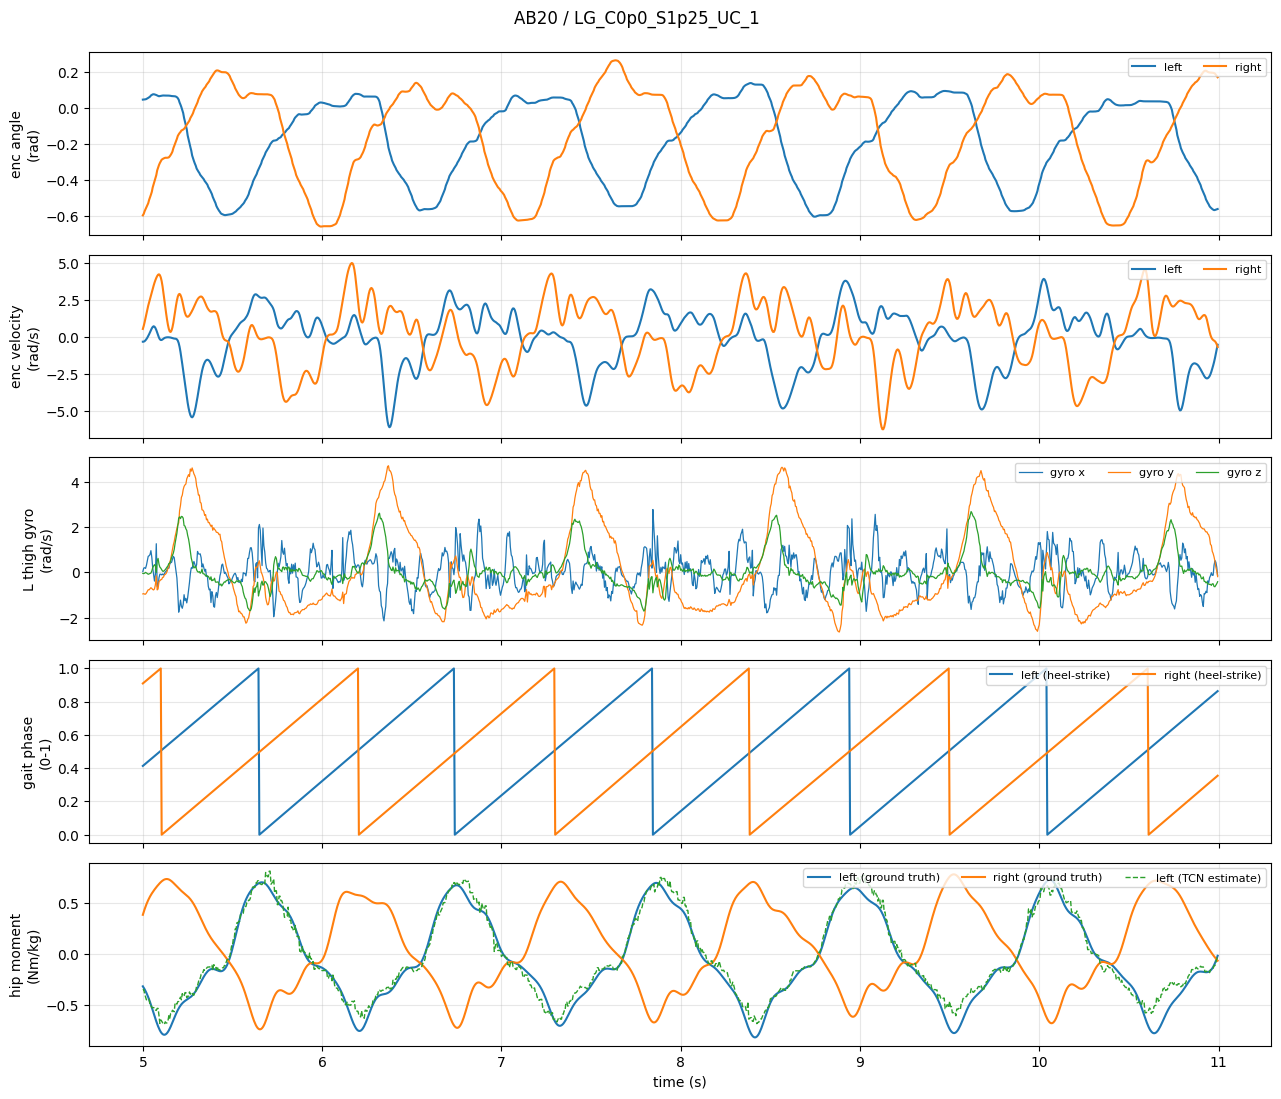

In [42]:
def plot_trial(subject: str, trial: str, t0: float = 5.0, dur: float = 6.0):
    df = load_trial(subject, trial)
    t = df["time"].to_numpy()
    t_rel = t - t[0]
    m = (t_rel >= t0) & (t_rel < t0 + dur)
    x = t_rel[m]

    fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True)

    axes[0].plot(x, df.loc[m, "enc_angle_l"], label="left")
    axes[0].plot(x, df.loc[m, "enc_angle_r"], label="right")
    axes[0].set_ylabel("enc angle\n(rad)")

    axes[1].plot(x, df.loc[m, "enc_velo_l"], label="left")
    axes[1].plot(x, df.loc[m, "enc_velo_r"], label="right")
    axes[1].set_ylabel("enc velocity\n(rad/s)")

    for ax_name in ("x", "y", "z"):
        axes[2].plot(x, df.loc[m, f"thigh_gyro_{ax_name}_l"], label=f"gyro {ax_name}", lw=0.9)
    axes[2].set_ylabel("L thigh gyro\n(rad/s)")

    axes[3].plot(x, df.loc[m, "gp_hs_l"], label="left (heel-strike)")
    axes[3].plot(x, df.loc[m, "gp_hs_r"], label="right (heel-strike)")
    axes[3].set_ylabel("gait phase\n(0-1)")

    axes[4].plot(x, df.loc[m, "hip_moment_l"], label="left (ground truth)")
    axes[4].plot(x, df.loc[m, "hip_moment_r"], label="right (ground truth)")
    if df["trq_est_l"].notna().any():
        axes[4].plot(x, df.loc[m, "trq_est_l"], "--", label="left (TCN estimate)", lw=1)
    axes[4].set_ylabel("hip moment\n(Nm/kg)")
    axes[4].set_xlabel("time (s)")

    for ax in axes:
        ax.legend(loc="upper right", fontsize=8, ncol=3)
        ax.grid(alpha=0.3)
    fig.suptitle(f"{subject} / {trial}", y=0.995)
    fig.tight_layout()
    return fig


plot_trial("AB20", "LG_C0p0_S1p25_UC_1");

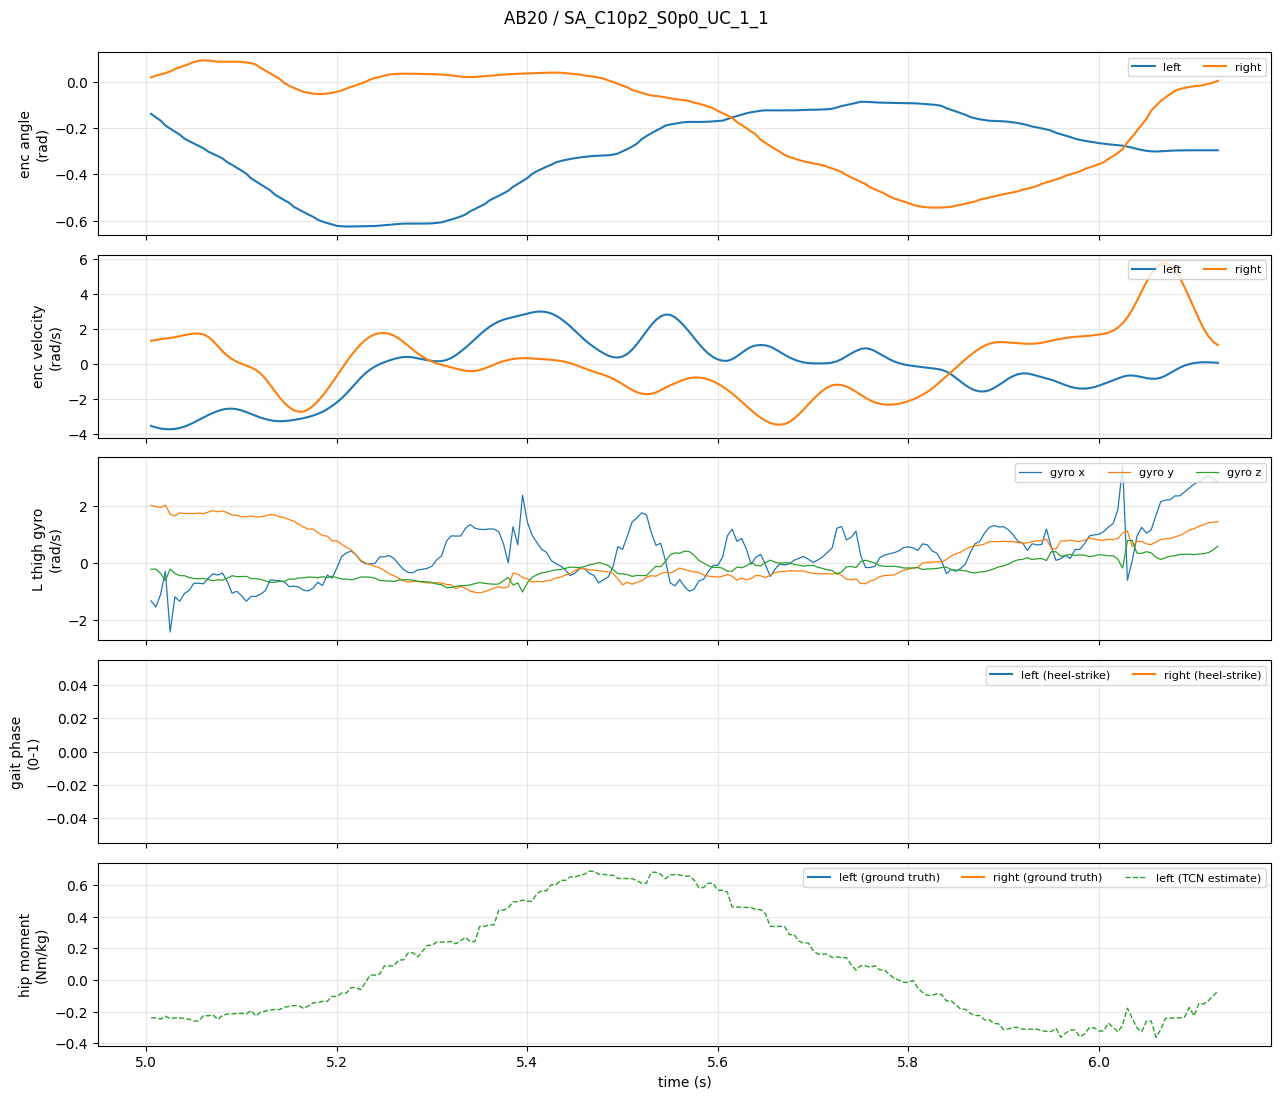

In [25]:
# A treadmill trial keeps the participant on the instrumented belt, so ground truth is dense.
# Compare against an overground stair trial, where mocap/GRF coverage is patchy.
plot_trial("AB20", inventory.query("subject == 'AB20' and mode == 'SA'")["trial"].iloc[0]);

## 5. Bulk loading

`iter_trials()` streams trials matching an inventory filter so you never hold the whole 6.1 GB
in memory. `build_parquet_cache()` does a one-time conversion of the CSVs to Parquet — roughly
an order of magnitude faster to re-read, and much smaller on disk.

In [43]:
def select(
    subjects: list[str] | None = None,
    modes: list[str] | None = None,
    controllers: list[str] | None = None,
    phases: list[int] | None = None,
    exo_hardware: str | None = None,
    min_duration_s: float = 0.0,
) -> pd.DataFrame:
    """Filter the inventory down to the trials you want."""
    df = inventory[inventory["complete"]]
    if subjects is not None:
        df = df[df["subject"].isin(subjects)]
    if modes is not None:
        df = df[df["mode"].isin(modes)]
    if controllers is not None:
        df = df[df["controller"].isin(controllers)]
    if phases is not None:
        df = df[df["phase"].isin(phases)]
    if exo_hardware is not None:
        df = df[df["exo_hardware"] == exo_hardware]
    return df[df["duration_s"] >= min_duration_s]


def iter_trials(sel: pd.DataFrame, files: list[str] | None = None, add_meta: bool = True):
    """Yield (metadata_row, DataFrame) for each selected trial, one at a time."""
    for r in sel.itertuples():
        yield r, load_trial(r.subject, r.trial, files=files, add_meta=add_meta)


# Example: the custom-exo treadmill trials, which most closely match the
# ankle paper's training set (treadmill locomotion at varying speed and incline).
sel = select(phases=[3, 4], modes=["LG", "RA", "RD"], exo_hardware="custom")
print(f"{len(sel)} trials | {sel['duration_s'].sum() / 3600:.2f} h | "
      f"{sel['subject'].nunique()} subjects")
display(sel.groupby(["mode", "controller"], observed=True)["duration_s"]
        .agg(trials="size", hours=lambda s: round(s.sum() / 3600, 2)))

446 trials | 4.48 h | 20 subjects


,,trials,hours
mode,controller,,
LG,UC,207,2.11
RA,UC,120,1.32
RD,UC,119,1.06


In [27]:
def build_parquet_cache(sel: pd.DataFrame, out_dir: Path | None = None, overwrite: bool = False) -> Path:
    """Convert selected trials to one Parquet file each. Run once; re-reads are far faster."""
    out_dir = out_dir or (CACHE / "trials")
    out_dir.mkdir(parents=True, exist_ok=True)
    written = skipped = 0
    for r in sel.itertuples():
        dest = out_dir / f"{r.subject}__{r.trial}.parquet"
        if dest.exists() and not overwrite:
            skipped += 1
            continue
        load_trial(r.subject, r.trial, add_meta=False).to_parquet(dest, index=False)
        written += 1
        if written % 100 == 0:
            print(f"  {written} written...")
    print(f"done: {written} written, {skipped} already cached -> {out_dir}")
    return out_dir


def load_cached(subject: str, trial: str, cache_dir: Path | None = None) -> pd.DataFrame:
    cache_dir = cache_dir or (CACHE / "trials")
    return pd.read_parquet(cache_dir / f"{subject}__{trial}.parquet")


# Uncommenting this will take a few minutes and write ~1-2 GB of Parquet.
# build_parquet_cache(sel)

In [44]:
# Quick timing comparison on a single trial
import time

t0 = time.perf_counter(); _ = load_trial("AB20", "LG_C0p0_S1p25_UC_1"); csv_s = time.perf_counter() - t0
print(f"load_trial from CSV: {csv_s:.2f} s")

_dest = CACHE / "trials"; _dest.mkdir(parents=True, exist_ok=True)
_p = _dest / "AB20__LG_C0p0_S1p25_UC_1.parquet"
if not _p.exists():
    load_trial("AB20", "LG_C0p0_S1p25_UC_1").to_parquet(_p, index=False)
t0 = time.perf_counter(); _ = pd.read_parquet(_p); pq_s = time.perf_counter() - t0
print(f"same trial from Parquet: {pq_s:.2f} s  ({csv_s / max(pq_s, 1e-9):.1f}x faster)")

load_trial from CSV: 0.14 s
same trial from Parquet: 0.01 s  (16.5x faster)
